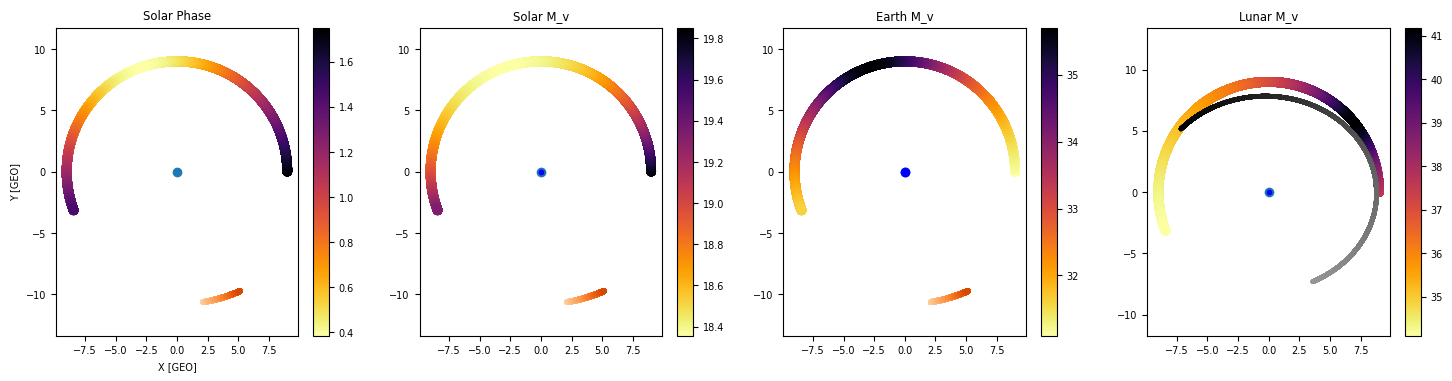

In [115]:
import yeager_utils as ut
import numpy as np
import matplotlib.pyplot as plt
import ssapy
from ssapy.body import get_body
from ssapy.constants import RGEO, MOON_RADIUS, EARTH_RADIUS

def getAngle(a, b, c):  # a,b,c where b is the vertex
    a = np.atleast_2d(a)
    b = np.atleast_2d(b)
    c = np.atleast_2d(c)
    ba = np.subtract(a, b)
    bc = np.subtract(c, b)
    cosine_angle = np.sum(ba * bc, axis=-1) / (np.linalg.norm(ba, axis=-1) * np.linalg.norm(bc, axis=-1))
    return np.arccos(cosine_angle)


def M_v_lambertian(r_sat, times, radius=1.0, albedo=0.20, sun_Mag=4.80, albedo_earth=0.30, albedo_moon=0.12, plot=False):
    pc_to_m = 3.085677581491367e+16
    r_sun = get_body('Sun').position(times).T
    r_moon = get_body('Moon').position(times).T
    r_earth = np.zeros_like(r_sun)

    r_sun_sat = np.linalg.norm(r_sat - r_sun, axis=-1)
    r_earth_sat = np.linalg.norm(r_sat, axis=-1)
    r_moon_sat = np.linalg.norm(r_sat - r_moon, axis=-1)
    
    sun_angle = getAngle(r_sun, r_sat, r_earth)
    earth_angle = np.pi - sun_angle
    moon_phase_angle = getAngle(r_sun, r_moon, r_sat)  # Phase of the moon as viewed from the sat.
    moon_to_earth_angle = getAngle(r_moon, r_sat, r_earth)

    flux_moon_to_sat = 2 / 3 * albedo_moon * MOON_RADIUS**2 / (np.pi * (r_moon_sat)**2) * (np.sin(moon_phase_angle) + (np.pi - moon_phase_angle) * np.cos(moon_phase_angle))  # Fraction of sunlight reflected from the Moon to satellite
    flux_earth_to_sat = 2 / 3 * albedo_earth * EARTH_RADIUS**2 / (np.pi * (r_earth_sat)**2) * (np.sin(earth_angle) + (np.pi - earth_angle) * np.cos(earth_angle))  # Fraction of sunlight reflected from the Earth to satellite

    frac_flux_sun = 2 / 3 * albedo * radius**2 / (np.pi * (r_earth_sat)**2) * (np.sin(sun_angle) + (np.pi - sun_angle) * np.cos(sun_angle))  # Fraction of light reflected off satellite from Sun
    frac_flux_earth = 2 / 3 * albedo * radius**2 / (np.pi * r_earth_sat**2) * flux_earth_to_sat
    frac_flux_moon = 2 / 3 * albedo * radius**2 / (np.pi * r_earth_sat**2) * flux_moon_to_sat
    Mag_v = (2.5 * np.log10((r_sun_sat / (10 * pc_to_m))**2) + sun_Mag) - 2.5 * np.log10(frac_flux_sun + frac_flux_earth + frac_flux_moon)
    if plot:
        import matplotlib.pyplot
        sun_scale = 149597870700.0 * (RGEO / np.max(r_earth_sat) ) * 0.75
        color_map ='inferno_r'
        fig = plt.figure(figsize=(18, 4))
        ax = fig.add_subplot(1, 4, 1)
        ax.scatter(earth[0], earth[1])
        scatter = ax.scatter(r[:, 0] / RGEO, r[:, 1] / RGEO, c=sun_angle, cmap=color_map)
        colorbar = plt.colorbar(scatter)
        ax.scatter(r_sun[:, 0] / sun_scale, r_sun[:, 1] / sun_scale, c=plt.cm.Oranges(np.linspace(0.25, 0.75, len(r[:, 0]))), s=10)
        ax.set_title('Solar Phase')
        ax.set_xlabel('X [GEO]')
        ax.set_ylabel('Y [GEO]')
        ax.axis('equal')

        ax = fig.add_subplot(1, 4, 2)
        ax.scatter(earth[0], earth[1])
        scatter = ax.scatter(r[:, 0] / RGEO, r[:, 1] / RGEO, c=(2.5 * np.log10((r_sun_sat / (10 * pc_to_m))**2) + sun_Mag) - 2.5 * np.log10(frac_flux_sun), cmap=color_map)
        colorbar = plt.colorbar(scatter)
        ax.scatter(0, 0, c='Blue', s=10)
        ax.scatter(r_sun[:, 0] / sun_scale, r_sun[:, 1] / sun_scale, c=plt.cm.Oranges(np.linspace(0.25, 0.75, len(r[:, 0]))), s=10)
        ax.set_title('Solar M_v')
        ax.axis('equal')

        ax = fig.add_subplot(1, 4, 3)
        ax.scatter(earth[0], earth[1])
        scatter = ax.scatter(r[:, 0] / RGEO, r[:, 1] / RGEO, c=(2.5 * np.log10((r_sun_sat / (10 * pc_to_m))**2) + sun_Mag) - 2.5 * np.log10(frac_flux_earth), cmap=color_map)
        colorbar = plt.colorbar(scatter)
        ax.scatter(r_sun[:, 0] / sun_scale, r_sun[:, 1] / sun_scale, c=plt.cm.Oranges(np.linspace(0.25, 0.75, len(r[:, 0]))), s=10)
        ax.scatter(0, 0, c='Blue', label="Earth")

        ax.set_title('Earth M_v')
        ax.axis('equal')

        ax = fig.add_subplot(1, 4, 4)
        ax.scatter(earth[0], earth[1])
        scatter = ax.scatter(r[:, 0] / RGEO, r[:, 1] / RGEO, c=(2.5 * np.log10((r_sun_sat / (10 * pc_to_m))**2) + sun_Mag) - 2.5 * np.log10(frac_flux_moon), cmap=color_map)
        ax.scatter(0, 0, c='Blue', s=10)
        ax.scatter(r_moon[:, 0] / RGEO, r_moon[:, 1] / RGEO, c=plt.cm.Greys(np.linspace(0.5, 1, len(r[:, 0]))), s=5)
        
        colorbar = plt.colorbar(scatter)
        ax.set_title('Lunar M_v')
        ax.axis('equal')
        plt.show()

    return Mag_v

times = ut.get_times(duration=(15, 'days'), freq=(1, 'min'), t=ut.Time("2025-1-1"))
r_sun = get_body('Sun').position(times).T
r_moon = get_body('Moon').position(times).T
r, v = ssapy.rv(ssapy.Orbit.fromKeplerianElements(*[9 * ut.RGEO, 0, 0, 0, 0, 0], t=times[0]), times, propagator=ssapy.RK78Propagator(ssapy.AccelKepler(), h=10.0))
Mv = M_v_lambertian(r, times, radius=1, plot=True)
